In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import os

# Cấu hình chung
os.makedirs('../figures', exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

LAT = 10.823
LON = 106.6296
YEAR = 2024
LOCATION = "TP.HCM"

print("--- BẮT ĐẦU PHÁT HIỆN BẤT THƯỜNG BẰNG MACHINE LEARNING ---")


daily_path = f'../processed/daily_weather_aqi_{LAT}_{LON}_{YEAR}.csv'
try:
    df = pd.read_csv(daily_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    print(f" Đã tải dữ liệu: {len(df)} ngày.")
except FileNotFoundError:
    print(" LỖI: Không tìm thấy file dữ liệu daily.")
    # Tạo dữ liệu giả để code không lỗi khi bạn copy
    dates = pd.date_range('2024-01-01', periods=365)
    df = pd.DataFrame({'date': dates, 'pm2_5_mean': np.random.rand(365)*50, 'wind_speed_mean': np.random.rand(365)*10})

--- BẮT ĐẦU PHÁT HIỆN BẤT THƯỜNG BẰNG MACHINE LEARNING ---
 Đã tải dữ liệu: 366 ngày.


In [5]:


import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

features = ['pm2_5_mean', 'wind_speed_mean', 'precip_total', 'temp_mean']

print(f" KIỂM TRA DỮ LIỆU ĐẦU VÀO (Tổng: {len(df)} ngày):")

missing_rain = df['precip_total'].isnull().sum()
print(f"   ->  Có {missing_rain} ngày bị thiếu dữ liệu mưa (NaN).")

data_ml = df[features].copy()

cols_continuous = ['pm2_5_mean', 'wind_speed_mean', 'temp_mean']
data_ml[cols_continuous] = data_ml[cols_continuous].interpolate(method='linear', limit_direction='both')

data_ml = data_ml.dropna(subset=['precip_total'])

print(f" Đã loại bỏ {len(df) - len(data_ml)} dòng thiếu dữ liệu.")
print(f" Dữ liệu SẠCH còn lại để chạy mô hình: {len(data_ml)} dòng.")

iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

print("\nĐang huấn luyện mô hình Isolation Forest...")

df.loc[data_ml.index, 'anomaly_score'] = iso_forest.fit_predict(data_ml)

df['anomaly_score'] = df['anomaly_score'].fillna(1) 

df['is_anomaly'] = (df['anomaly_score'] == -1).astype(int)

anomalies = df[df['is_anomaly'] == 1].sort_values('date')

print(f" Tìm thấy tổng cộng {len(anomalies)} ngày bất thường.")
print("\n" + "="*80)
print(f"DANH SÁCH CHI TIẾT {len(anomalies)} NGÀY BẤT THƯỜNG ")
print("="*80)

print(anomalies[['date'] + features].to_string(index=False))

output_file = '../processed/anomalies_list.csv'
anomalies[['date'] + features].to_csv(output_file, index=False)
print(f"\nĐã lưu danh sách vào: {output_file}")

 KIỂM TRA DỮ LIỆU ĐẦU VÀO (Tổng: 366 ngày):
   ->  Có 12 ngày bị thiếu dữ liệu mưa (NaN).
 Đã loại bỏ 12 dòng thiếu dữ liệu.
 Dữ liệu SẠCH còn lại để chạy mô hình: 354 dòng.

Đang huấn luyện mô hình Isolation Forest...
 Tìm thấy tổng cộng 18 ngày bất thường.

DANH SÁCH CHI TIẾT 18 NGÀY BẤT THƯỜNG 
      date  pm2_5_mean  wind_speed_mean  precip_total  temp_mean
2024-05-28       28.44              9.8          39.1       29.9
2024-06-23       18.46             20.9          14.5       27.6
2024-07-13       16.25             16.7          29.4       28.0
2024-07-14       13.85             18.1          12.2       26.8
2024-07-17       15.24             19.0          14.4       26.4
2024-09-06       11.76             20.1          10.9       28.2
2024-09-07       13.08             20.8          12.4       28.9
2024-09-08       19.91             16.4          26.4       28.8
2024-09-14       11.33             15.5          20.6       28.0
2024-09-18       17.14              8.5          25

DANH SÁCH TOP 5 NGÀY Ô NHIỄM NHẤT ĐỂ BẠN THAM KHẢO
      date  pm2_5_mean  wind_speed_mean
2024-12-30       54.40              8.4
2024-11-23       51.91              5.7
2024-12-04       49.32              7.8
2024-12-21       46.24              5.9
2024-12-22       41.60              8.7
------------------------------------------------------------

 Đang phân tích sự kiện Top 2: Ngày 2024-11-23 00:00:00
   (PM2.5: 51.91 µg/m³ | Gió: 5.70 km/h)


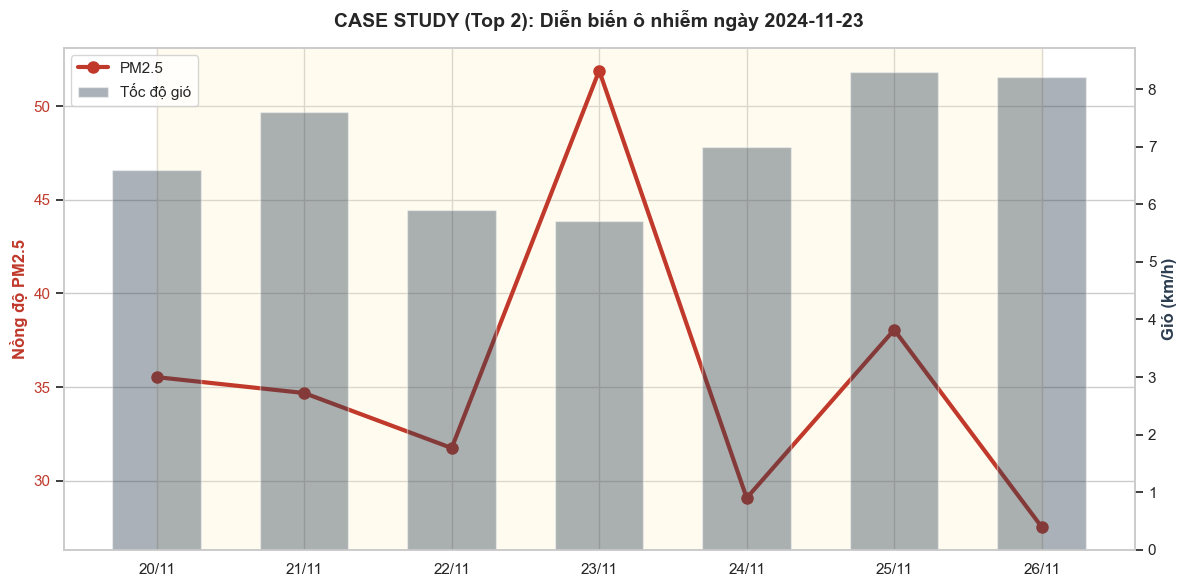

 Đã lưu biểu đồ tại: ../figures/15_case_study_rank2_2024-11-23.pdf


In [6]:
import matplotlib.dates as mdates

RANK_INPUT = 2  
RANK_INDEX = RANK_INPUT - 1

print("="*60)
print(f"DANH SÁCH TOP 5 NGÀY Ô NHIỄM NHẤT ĐỂ BẠN THAM KHẢO")
print("="*60)
sorted_events = anomalies.sort_values('pm2_5_mean', ascending=False)
print(sorted_events[['date', 'pm2_5_mean', 'wind_speed_mean']].head(5).to_string(index=False))
print("-" * 60)

# Kiểm tra và Vẽ
if not anomalies.empty and len(anomalies) > RANK_INDEX:
    # Lấy sự kiện
    target_event = sorted_events.iloc[RANK_INDEX]
    TARGET_DATE = target_event['date']
    
    print(f"\n Đang phân tích sự kiện Top {RANK_INPUT}: Ngày {TARGET_DATE}")
    print(f"   (PM2.5: {target_event['pm2_5_mean']:.2f} µg/m³ | Gió: {target_event['wind_speed_mean']:.2f} km/h)")

    # Tạo khung thời gian 7 ngày
    window_days = 3
    target_ts = pd.to_datetime(TARGET_DATE)
    start_date = target_ts - pd.Timedelta(days=window_days)
    end_date = target_ts + pd.Timedelta(days=window_days)

    mask = (df['date'] >= start_date) & (df['date'] <= end_date)
    df_window = df.loc[mask].copy()

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.axvspan(start_date, end_date, color='#fff3cd', alpha=0.3)
    ax1.plot(df_window['date'], df_window['pm2_5_mean'], 
             color='#c0392b', marker='o', markersize=8, linewidth=3, label='PM2.5')
    
    ax1.set_ylabel('Nồng độ PM2.5', color='#c0392b', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#c0392b')
    
    title_date = target_ts.strftime('%Y-%m-%d')
    ax1.set_title(f'CASE STUDY (Top {RANK_INPUT}): Diễn biến ô nhiễm ngày {title_date}', 
                  fontsize=14, fontweight='bold', pad=15)

    ax2 = ax1.twinx()
    ax2.bar(df_window['date'], df_window['wind_speed_mean'], 
            alpha=0.4, color='#2c3e50', width=0.6, label='Tốc độ gió')
    ax2.set_ylabel('Gió (km/h)', color='#2c3e50', fontweight='bold')
    ax2.grid(False)

    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.tight_layout()

    output_path = f'../figures/15_case_study_rank{RANK_INPUT}_{title_date}.pdf'
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    plt.show()
    print(f" Đã lưu biểu đồ tại: {output_path}")

else:
    print(f" Không tìm thấy ngày Top {RANK_INPUT}. Danh sách chỉ có {len(anomalies)} ngày.")